# VLM training  notebook 

(using a custom VIT and a pretrained siglip encoder)

Thin orchestration notebook: imports models from `GPT.py`, `ViT.py`, `VLM.py` and other python files needed for training 

In [5]:
import os
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '../src')
sys.path.insert(0, '../src/model')

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoTokenizer

from src.model.gpt import GPT
from src.model.vit import ViT
from src.model.vlm import VLM, CustomViTAdapter, SigLIPAdapter
from src.configs import (
    ConfigParametersLLM,
    ConfigParametersViT,
    ConfigParametersVLM,
    OptimParametersVLM,
)
from src.vision_datasets import val_tfm, train_tfm, build_vlm_dataloaders, build_coco_dataloaders
from src.train_helper import validate_vlm
from src.utils import vlm_from_config, llm_from_config, vision_encoder_from_config, draw_plot
from src.train_vlm import save_checkpoint, train_vlm
from src.inference_helper import prepare_inference_input


from transformers import SiglipVisionModel

## Setup: tokenizer, device, data and model paths

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token


VLM_OUTPUT_DIR = "../outputs/vlm_siglip"
DATA_DIR = "../data/coco"

if  not os.path.exists(VLM_OUTPUT_DIR):
    os.makedirs(VLM_OUTPUT_DIR, exist_ok=True)

## Build configs

In [3]:
"""for custom vit use: 
"vision_encoder": {
          "type": "custom_vit",
          "config_path": "../configs/custom_vit_config_params.json",
    }
"""

vlm_config = {
    "device": device,

    
    "vision_encoder": {
      "type": "siglip",
      "model_name": "google/siglip-base-patch16-224"
      },


    "llm": {
          "type": "custom_gpt",
          "config_path": "../configs/custom_gpt_config_params.json",
          "checkpoint_path": "../outputs/llm_rope/llm_wikitext_rope_final.pt"
    },

    "vlm": {
          "batch_size": 32,
          "output_dim": 768 #vision encoder linear projection dim
    },

    "optim": {
            "lr": 1e-4, #learning rate
            "min_lr": 1e-5, #minimum learning rate
            "betas": (0.9, 0.95), #betas
            "eps": 1e-8, #epsilon
            "scheduler": True, #use a learning rate scheduler
            "compile": True, #compile the model
            "autocast": True, #autocast
            "autocast_dtype": torch.bfloat16, #autocast dtype
            "min_lr": 1e-5, #minimum learning rate
            "warmup_steps": 500, #warmup steps
            "max_steps": 40000 #max steps
    }
  }

## Build VLM and optimizer

In [ ]:
vlm_model = vlm_from_config(vlm_config).to(device)
opt_cfg = OptimParametersVLM(**vlm_config["optim"])

optimizer = torch.optim.AdamW(
    [p for p in vlm_model.parameters() if p.requires_grad],
    lr=opt_cfg.lr, betas=opt_cfg.betas, eps=opt_cfg.eps,
)

scheduler = None
if opt_cfg.scheduler is not None:
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=opt_cfg.max_steps)

if opt_cfg.compile is not None:
    vlm_model = torch.compile(vlm_model)

Loading weights: 100%|██████████| 208/208 [00:00<00:00, 1339.64it/s, Materializing param=vision_model.post_layernorm.weight]                      
SiglipVisionModel LOAD REPORT from: google/siglip-base-patch16-224
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNE

## Build dataloaders

In [4]:
train_loader, val_loader = build_coco_dataloaders(                                                                                                                                    
      tokenizer,
      batch_size=vlm_config["vlm"]["batch_size"],                                                                                                                                                                   
      num_workers=4, 
      data_dir=DATA_DIR,                                       
      # val_limit=500 by default — 500 pairs for quick eval
      # train_limit=None      — use all 591K train pairs                                                                                                                                
  )
print(f"train batches: {len(train_loader):,}")   # ~18,500 at batch=32                                                                                                                
print(f"val batches:   {len(val_loader):,}")     # ~16 at batch=32, val_limit=500 

train batches: 18,493
val batches:   16


## VLM training with custom ViT and custom GPT

In [16]:
###with rope embeddings
train_loss_r, val_loss_r = train_vlm(
    vlm_model, train_loader, val_loader, optimizer, device,
    opt_cfg=opt_cfg, scheduler=scheduler, output_dir=VLM_OUTPUT_DIR,
    max_steps=opt_cfg.max_steps, validation=True
)


Step 2000 | Loss 2.5671
Step 4000 | Loss 2.8636
Checkpoint saved at step 4000
Validation loss: 2.8922
Step 6000 | Loss 2.7945
Step 8000 | Loss 2.4798
Checkpoint saved at step 8000
Validation loss: 2.8566
Step 10000 | Loss 2.6643
Step 12000 | Loss 2.0024
Checkpoint saved at step 12000
Validation loss: 2.8227
Step 14000 | Loss 2.4654
Step 16000 | Loss 2.5554
Checkpoint saved at step 16000
Validation loss: 2.7750
Step 18000 | Loss 2.2770
Step 20000 | Loss 2.5466
Checkpoint saved at step 20000
Validation loss: 2.7374
Step 22000 | Loss 2.3029
Step 24000 | Loss 2.6324
Checkpoint saved at step 24000
Validation loss: 2.7184
Step 26000 | Loss 2.6406
Step 28000 | Loss 2.4748
Checkpoint saved at step 28000
Validation loss: 2.7014
Step 30000 | Loss 2.2535
Step 32000 | Loss 2.3898
Checkpoint saved at step 32000
Validation loss: 2.7121
Step 34000 | Loss 2.3635
Step 36000 | Loss 2.1513
Checkpoint saved at step 36000
Validation loss: 2.6829
Step 38000 | Loss 2.1238
Step 40000 | Loss 2.1649
Checkpoint 

## plot train and val loss

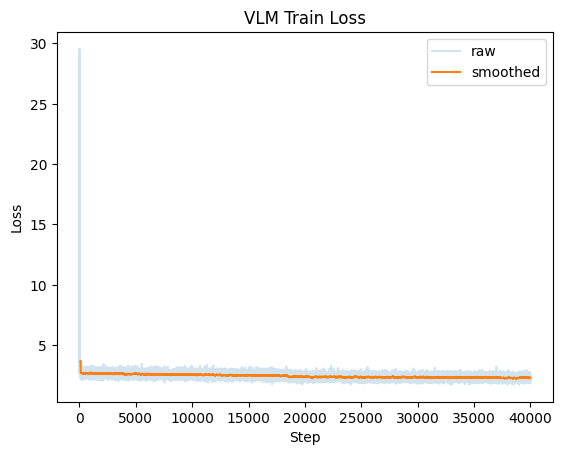

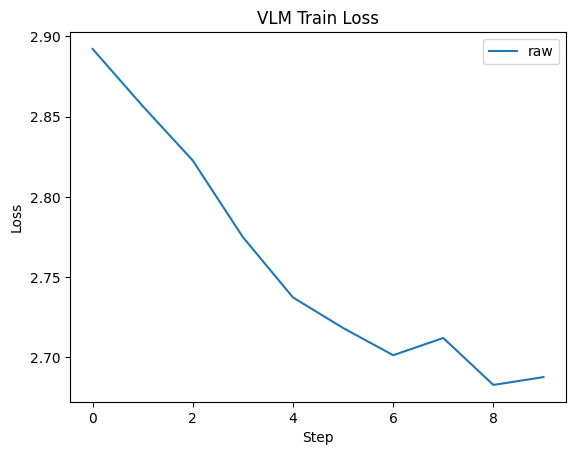

In [40]:
draw_plot(train_loss_r)
draw_plot(val_loss_r)

## Inference 

In [18]:
#load VLM model



vlm_config_r = {

    "device": device,

    
    "vision_encoder": {
          "type": "custom_vit",
          "config_path": "../configs/custom_vit_config_params.json"
    },


    "llm": {
          "type": "custom_gpt",
          "config_path": "../configs/custom_gpt_config_params.json",
          "checkpoint_path": "../outputs/llm_rope/llm_wikitext_rope_final.pt"
    },

    "vlm": {
          "batch_size": 32,
          "output_dim": 768 #vision encoder linear projection dim
    },

    "optim": {
            "lr": 1e-4, #learning rate
            "min_lr": 1e-5, #minimum learning rate
            "betas": (0.9, 0.95), #betas
            "eps": 1e-8, #epsilon
            "scheduler": True, #use a learning rate scheduler
            "compile": True, #compile the model
            "autocast": True, #autocast
            "autocast_dtype": torch.bfloat16, #autocast dtype
            "min_lr": 1e-5, #minimum learning rate
            "warmup_steps": 500, #warmup steps
            "max_steps": 40000 #max steps
    }
  }
ckpt = torch.load("../outputs/vlm_rope/vlm_coco_captions_rope_final.pt")
state_dict = {k.removeprefix("_orig_mod."): v for k, v in ckpt["model"].items()}

#for backward compatibility with custom vit, new models have a vision_encoder.vit. prefix
fixed_state_dict = {}
for k, v in state_dict.items():
      if k.startswith("vision_encoder.") and not k.startswith("vision_encoder.vit."):
          new_k = k.replace("vision_encoder.", "vision_encoder.vit.", 1)
      else:
          new_k = k
      fixed_state_dict[new_k] = v

                                              
vlm_model = vlm_from_config(vlm_config_r).to(device)                                                                                                                       
vlm_model.load_state_dict(fixed_state_dict)                                                                                                                                                 
vlm_model.to(device)                                                                                                                                                                  
vlm_model.eval()  

VLM(
  (vision_encoder): CustomViTAdapter(
    (vit): ViT(
      (blocks): ModuleList(
        (0-3): 4 x TransformerBlock(
          (MHSA): MultiHeadAttention(
            (q_proj): Linear()
            (k_proj): Linear()
            (v_proj): Linear()
            (o_proj): Linear()
            (pos_emb): RotaryPositionalEmbeddings()
          )
          (layernorm1): LayerNormalization()
          (layernorm2): LayerNormalization()
          (FFN): Sequential(
            (0): Linear()
            (1): GLU()
            (2): Linear()
          )
        )
      )
      (logit_proj): Linear()
      (x_proj): Linear()
    )
  )
  (LLM): GPT(
    (blocks): ModuleList(
      (0-3): 4 x TransformerBlock(
        (MHSA): MultiHeadAttention(
          (q_proj): Linear()
          (k_proj): Linear()
          (v_proj): Linear()
          (o_proj): Linear()
          (pos_emb): RotaryPositionalEmbeddings()
        )
        (layernorm1): LayerNormalization()
        (layernorm2): LayerNorma

text_tokens: [7571, 661, 5586, 319, 257, 18757, 287, 262, 4675, 1306, 284, 257, 10481, 13, 50256]
caption (decoded): 'Two people sitting on a motorcycle in the street next to a beach.'

image path: ../data/coco/val2017/000000102411.jpg
caption used at idx 350: 'Two people sitting on a motorcycle in the street next to a beach.'


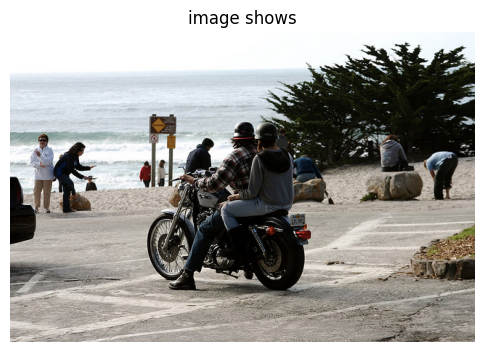

 a man riding a motorcycle down a street.


In [19]:
idx = 350                                                                                                 
                                                                                                                                                                                        
# Inspect what the dataloader sees       
val_ds  = val_loader.dataset                                                                                                                                             
sample = val_ds[idx]                                                                                                                                                                  
print(f"text_tokens: {sample['text_tokens'].tolist()}")                                                                                                                               
print(f"caption (decoded): {tokenizer.decode(sample['text_tokens'], skip_special_tokens=True)!r}")                                                                                    
                                                                                                                                                                                        
# Image path + all reference captions for this image                                                                                                                                  
file_name, caption_used = val_ds.samples[idx]                                                                                                                                         
image_path = os.path.join(val_ds.image_dir, file_name)                                                                                                                                
print(f"\nimage path: {image_path}")                                                                                                                                                  
print(f"caption used at idx {idx}: {caption_used!r}") 

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "path": image_path,
            },
            {
                "type": "text",
                "text": "image shows"
            },
        ],
    }
]

vlm_model.eval()
inputs = prepare_inference_input(messages, tokenizer, max_len=512, transform=val_tfm)
image = inputs["image"].to(device)
text_tokens = inputs["text_tokens"].to(device)
attention_mask = inputs["attention_mask"].to(device)

with torch.inference_mode():
    generated_ids = vlm_model.generate(
        image,
        text_tokens,
        attention_mask,
        max_new_tokens=100,
        eos_token_id=tokenizer.eos_token_id,
    )

image_path = messages[0]["content"][0]["path"]
prompt_text = messages[0]["content"][1]["text"]

pil_img = Image.open(image_path).convert("RGB")
plt.figure(figsize=(6, 6))
plt.imshow(pil_img)
plt.axis("off")
plt.title(prompt_text)
plt.show()

print(tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0])

In [8]:
### Training with SigLIP vision encoder
train_loss_s, val_loss_s = train_vlm(
    vlm_model, train_loader, val_loader, optimizer, device,
    opt_cfg=opt_cfg, scheduler=scheduler, output_dir=VLM_OUTPUT_DIR,
    max_steps=opt_cfg.max_steps, validation=True
)


W0428 12:03:04.324000 336536 torch/_inductor/utils.py:1727] [0/0_1] Not enough SMs to use max_autotune_gemm mode


Step 2000 | Loss 2.8408
Step 4000 | Loss 2.6401
Checkpoint saved at step 4000
Validation loss: 2.8130
Step 6000 | Loss 2.4347
Step 8000 | Loss 2.8439
Checkpoint saved at step 8000
Validation loss: 2.7454
Step 10000 | Loss 2.2519
Step 12000 | Loss 2.3360
Checkpoint saved at step 12000
Validation loss: 2.6721
Step 14000 | Loss 2.9596
Step 16000 | Loss 2.2122
Checkpoint saved at step 16000
Validation loss: 2.6097
Step 18000 | Loss 2.3989
Step 20000 | Loss 2.2363
Checkpoint saved at step 20000
Validation loss: 2.5702
Step 22000 | Loss 2.2129
Step 24000 | Loss 2.2233
Checkpoint saved at step 24000
Validation loss: 2.5528
Step 26000 | Loss 2.0368
Step 28000 | Loss 1.7938
Checkpoint saved at step 28000
Validation loss: 2.5196
Step 30000 | Loss 2.1093
Step 32000 | Loss 2.0190
Checkpoint saved at step 32000
Validation loss: 2.4948
Step 34000 | Loss 2.7953
Step 36000 | Loss 2.1452
Checkpoint saved at step 36000
Validation loss: 2.4799
Step 38000 | Loss 2.0798
Step 40000 | Loss 1.9766
Checkpoint 

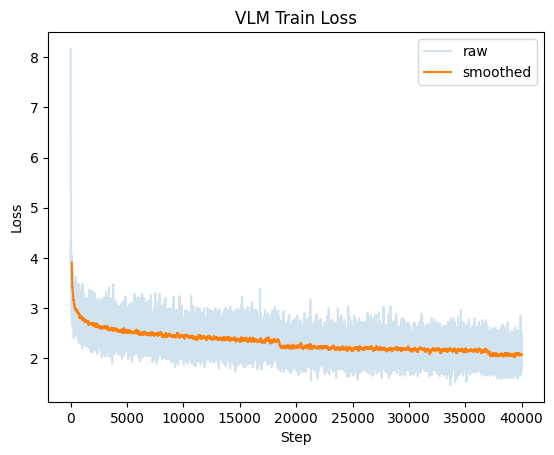

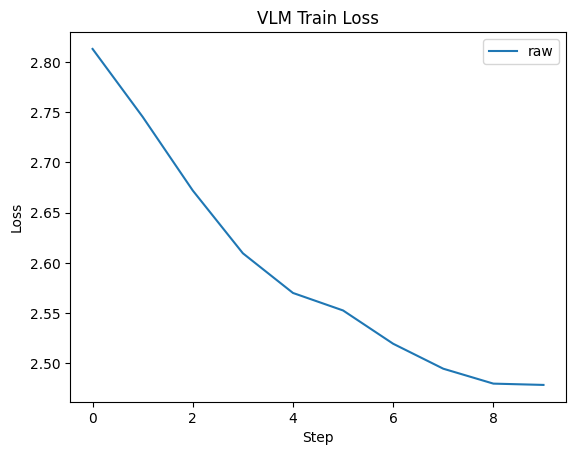

In [11]:
draw_plot(train_loss_s)
draw_plot(val_loss_s)

In [6]:
#load VLM model

ckpt = torch.load("../outputs/vlm_siglip/vlm_coco_captions_rope_final.pt")
state_dict = {k.removeprefix("_orig_mod."): v for k, v in ckpt["model"].items()}
                                              
vlm_model_s = vlm_from_config(vlm_config).to(device)                                                                                                                     
vlm_model_s.load_state_dict(state_dict)                                                                                                                                                 
vlm_model_s.to(device)                                                                                                                                                                  
vlm_model_s.eval()  

Loading weights: 100%|██████████| 208/208 [00:00<00:00, 1730.64it/s, Materializing param=vision_model.post_layernorm.weight]                      
SiglipVisionModel LOAD REPORT from: google/siglip-base-patch16-224
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNE

VLM(
  (vision_encoder): SigLIPAdapter(
    (model): SiglipVisionModel(
      (vision_model): SiglipVisionTransformer(
        (embeddings): SiglipVisionEmbeddings(
          (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), padding=valid)
          (position_embedding): Embedding(196, 768)
        )
        (encoder): SiglipEncoder(
          (layers): ModuleList(
            (0-11): 12 x SiglipEncoderLayer(
              (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
              (self_attn): SiglipAttention(
                (k_proj): Linear(in_features=768, out_features=768, bias=True)
                (v_proj): Linear(in_features=768, out_features=768, bias=True)
                (q_proj): Linear(in_features=768, out_features=768, bias=True)
                (out_proj): Linear(in_features=768, out_features=768, bias=True)
              )
              (layer_norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
              (mlp):

text_tokens: [32, 37370, 21223, 290, 257, 1976, 37052, 6155, 832, 281, 5510, 8631, 13, 50256]
caption (decoded): 'A giraffe and a zebra walking through an African plain.'

image path: ../data/coco/val2017/000000159977.jpg
caption used at idx 140: 'A giraffe and a zebra walking through an African plain.'


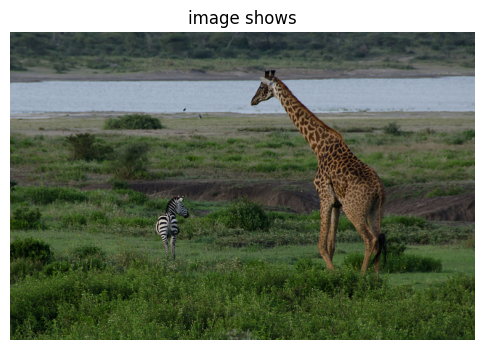

 a zebra and a giraffe in a grassy field.


In [20]:
idx = 140                                                                                  
                                                                                                                                                                                        
# Inspect what the dataloader sees       
val_ds  = val_loader.dataset                                                                                                                                             
sample = val_ds[idx]                                                                                                                                                                  
print(f"text_tokens: {sample['text_tokens'].tolist()}")                                                                                                                               
print(f"caption (decoded): {tokenizer.decode(sample['text_tokens'], skip_special_tokens=True)!r}")                                                                                    
                                                                                                                                                                                        
# Image path + all reference captions for this image                                                                                                                                  
file_name, caption_used = val_ds.samples[idx]                                                                                                                                         
image_path = os.path.join(val_ds.image_dir, file_name)                                                                                                                                
print(f"\nimage path: {image_path}")                                                                                                                                                  
print(f"caption used at idx {idx}: {caption_used!r}") 

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "path": image_path,
            },
            {
                "type": "text",
                "text": "image shows"
            },
        ],
    }
]

vlm_model_s.eval()
inputs = prepare_inference_input(messages, tokenizer, max_len=512, transform=val_tfm)
image = inputs["image"].to(device)
text_tokens = inputs["text_tokens"].to(device)
attention_mask = inputs["attention_mask"].to(device)

with torch.inference_mode():
    generated_ids = vlm_model_s.generate(
        image,
        text_tokens,
        attention_mask,
        max_new_tokens=100,
        eos_token_id=tokenizer.eos_token_id,
    )

image_path = messages[0]["content"][0]["path"]
prompt_text = messages[0]["content"][1]["text"]

pil_img = Image.open(image_path).convert("RGB")
plt.figure(figsize=(6, 6))
plt.imshow(pil_img)
plt.axis("off")
plt.title(prompt_text)
plt.show()

print(tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0])